# Bitcoin Price Forecasting with Heterogeneous Financial Indicators

## Problem Statement

**Research goal:** Predicting Bitcoin price using heterogeneous financial, macroeconomic, crypto-market and technical indicators, and comparing classical time-series, linear, tree-based, ensemble and neural forecasting methods.

The project is a supervised forecasting/data mining task. For each observation frequency, the feature vector available at time `t` is used to predict the Bitcoin price at `t+1`. This one-step-ahead framing avoids using same-period target information as if it were known before the forecast.

The target variable is `BTC`. The explanatory variables include crypto-market assets, equity/ETF proxies, commodities, FX rates, technical indicators, calendar variables, macroeconomic indicators, blockchain/market-sentiment variables, and lagged or rolling BTC features.


## Setup

The notebook uses frozen CSV datasets created by the existing data collection scripts. No external API call is required to reproduce the report.


In [1]:
import os
from pathlib import Path
import warnings
from collections import OrderedDict

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/private/tmp')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as pltЗ
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)


## Data Collection

The project uses three consolidated datasets from the existing BTC forecasting project:

- `new_day_df.csv`: daily observations.
- `new_hour_df.csv`: hourly observations.
- `new_5min_df.csv`: 5-minute observations.

The raw collection and merging logic is kept in `get_data.py`. The report uses the frozen CSV files so that all experiments are reproducible without network access. Every dataset used here has well above 50 objects and 7-10 features.


In [8]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'new_day_df.csv').exists():
    PROJECT_DIR = Path(__file__).parent if '__file__' in dir() else PROJECT_DIR

DATA_CONFIG = OrderedDict({
    'daily': {
        'file': 'new_day_df.csv',
        'date_col': 'Date',
        'test_size': 216,
        'horizon': 1,
        'ma_window': 7,
        'seasonal_period': 7,
        'max_features': 30,
    },
    'hourly': {
        'file': 'new_hour_df.csv',
        'date_col': 'Datetime',
        'test_size': 0.20,
        'horizon': 1,
        'ma_window': 24,
        'seasonal_period': 24,
        'max_features': 25,
    },
    '5min': {
        'file': 'new_5min_df.csv',
        'date_col': 'Datetime',
        'test_size': 0.20,
        'horizon': 1,
        'ma_window': 12,
        'seasonal_period': 288,
        'max_features': 20,
    },
})

def load_dataset(file_name, date_col):
    df = pd.read_csv(PROJECT_DIR / file_name, parse_dates=[date_col])
    df = df.sort_values(date_col).set_index(date_col)
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

datasets = {
    frequency: load_dataset(cfg['file'], cfg['date_col'])
    for frequency, cfg in DATA_CONFIG.items()
}

for frequency, df in datasets.items():
    print(f'{frequency}: {df.shape[0]} rows, {df.shape[1]} columns, {df.index.min()} -> {df.index.max()}')


daily: 2912 rows, 88 columns, 2018-06-20 00:00:00 -> 2026-06-09 00:00:00
hourly: 20922 rows, 68 columns, 2024-06-11 12:00:00 -> 2026-06-09 23:00:00
5min: 16589 rows, 68 columns, 2026-04-13 09:35:00 -> 2026-06-09 23:55:00


## Dataset Summary with Basic Statistics and Plots

This section checks dataset size, observation periods, feature groups, missing values, basic target statistics, and target distribution.


In [9]:
CRYPTO_COLS = {
    'BTC', 'ETH', 'Bitcoin_Cash', 'Cardano', 'Dogecoin', 'Ethereum_Classic',
    'Chainlink', 'Litecoin', 'TRON', 'Tether', 'Stellar', 'XRP', 'BTC_Supply',
    'Feer_Greed_value'
}
MACRO_COLS = {
    'Unemployment_Rate', 'Non_Farm_Payrolls', 'Initial_Jobless_Claims', 'CPI',
    'PCE_Price_Index', 'Consumer_Confidence_Index', 'Retail_Sales', 'Housing_Starts',
    'Building_Permits', 'M2_Money_Supply', 'Real_Interest_Rate', 'Fed_Funds_Rate',
    'Reverse_Repo_Volume', 'Debt', 'Real_GDP'
}
TECHNICAL_TOKENS = (
    'RSI', 'MACD', 'ATR', 'OBV', 'SMA', 'EMA', 'TEMA', 'KAMA', 'HMA', 'ALMA',
    'T3', 'SSF', 'VIDYA', 'ZL_EMA', 'BTC_lag', 'BTC_mean', 'BTC_std',
    'Open', 'High', 'Low', 'Close', 'Volume', 'Taker buy'
)
CALENDAR_COLS = {'day', 'month', 'quarter', 'year', 'day_of_week', 'hour', 'minute', 'is_holiday'}
FX_TOKENS = ('USD/', 'EUR/', 'GBP/', 'AUD/')
COMMODITY_COLS = {'Gold', 'Silver', 'Copper', 'Platinum', 'Brent_Oil', 'WTI', 'Brent', 'Natural_Gas'}

def feature_group(col):
    if col in CALENDAR_COLS:
        return 'calendar'
    if col in MACRO_COLS:
        return 'macroeconomic'
    if col in CRYPTO_COLS:
        return 'crypto-market'
    if col in COMMODITY_COLS:
        return 'commodities'
    if any(token in col for token in TECHNICAL_TOKENS):
        return 'technical/lagged BTC'
    if any(token in col for token in FX_TOKENS):
        return 'FX'
    return 'equity/ETF/market index'

summary_rows = []
group_rows = []
for frequency, df in datasets.items():
    target = df['BTC']
    missing_by_col = df.isna().sum()
    summary_rows.append({
        'frequency': frequency,
        'objects': len(df),
        'features_excluding_target': df.shape[1] - 1,
        'start': df.index.min(),
        'end': df.index.max(),
        'missing_values_total': int(missing_by_col.sum()),
        'columns_with_missing': int((missing_by_col > 0).sum()),
        'BTC_mean': target.mean(),
        'BTC_std': target.std(),
        'BTC_min': target.min(),
        'BTC_median': target.median(),
        'BTC_max': target.max(),
    })
    feature_groups = pd.Series([feature_group(col) for col in df.columns if col != 'BTC']).value_counts()
    for group, count in feature_groups.items():
        group_rows.append({'frequency': frequency, 'feature_group': group, 'count': int(count)})

summary_df = pd.DataFrame(summary_rows)
feature_group_df = pd.DataFrame(group_rows).sort_values(['frequency', 'feature_group'])

display(summary_df)
display(feature_group_df.pivot_table(index='feature_group', columns='frequency', values='count', fill_value=0).astype(int))


,frequency,objects,features_excluding_target,start,end,missing_values_total,columns_with_missing,BTC_mean,BTC_std,BTC_min,BTC_median,BTC_max
0,daily,2912,87,2018-06-20 00:00:00,2026-06-09 00:00:00,0,0,40986.414848,32640.358450,3235.051208,31075.478516,124724.794922
1,hourly,20922,67,2024-06-11 12:00:00,2026-06-09 23:00:00,0,0,87500.946850,18841.613509,50197.403320,88479.541016,125897.021484
2,5min,16589,67,2026-04-13 09:35:00,2026-06-09 23:55:00,0,0,75389.482533,5332.657816,59203.291992,76850.546875,82722.105469


frequency,5min,daily,hourly
feature_group,,,
FX,6,6,6
calendar,2,5,2
crypto-market,11,13,11
equity/ETF/market index,38,38,38
macroeconomic,0,15,0
technical/lagged BTC,10,10,10


In [10]:
basic_stats = pd.concat(
    {frequency: df['BTC'].describe() for frequency, df in datasets.items()},
    axis=1
).T
basic_stats['skew'] = [datasets[f]['BTC'].skew() for f in basic_stats.index]
basic_stats['kurtosis'] = [datasets[f]['BTC'].kurtosis() for f in basic_stats.index]
display(basic_stats.round(2))


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
daily,2912.0,40986.41,32640.36,3235.05,10365.88,31075.48,63451.00,124724.79,0.75,-0.54
hourly,20922.0,87500.95,18841.61,50197.40,68795.79,88479.54,103877.84,125897.02,0.02,-1.22
5min,16589.0,75389.48,5332.66,59203.29,74247.62,76850.55,78398.89,82722.11,-1.48,1.39


In [12]:
import matplotlib.pyplot as plt

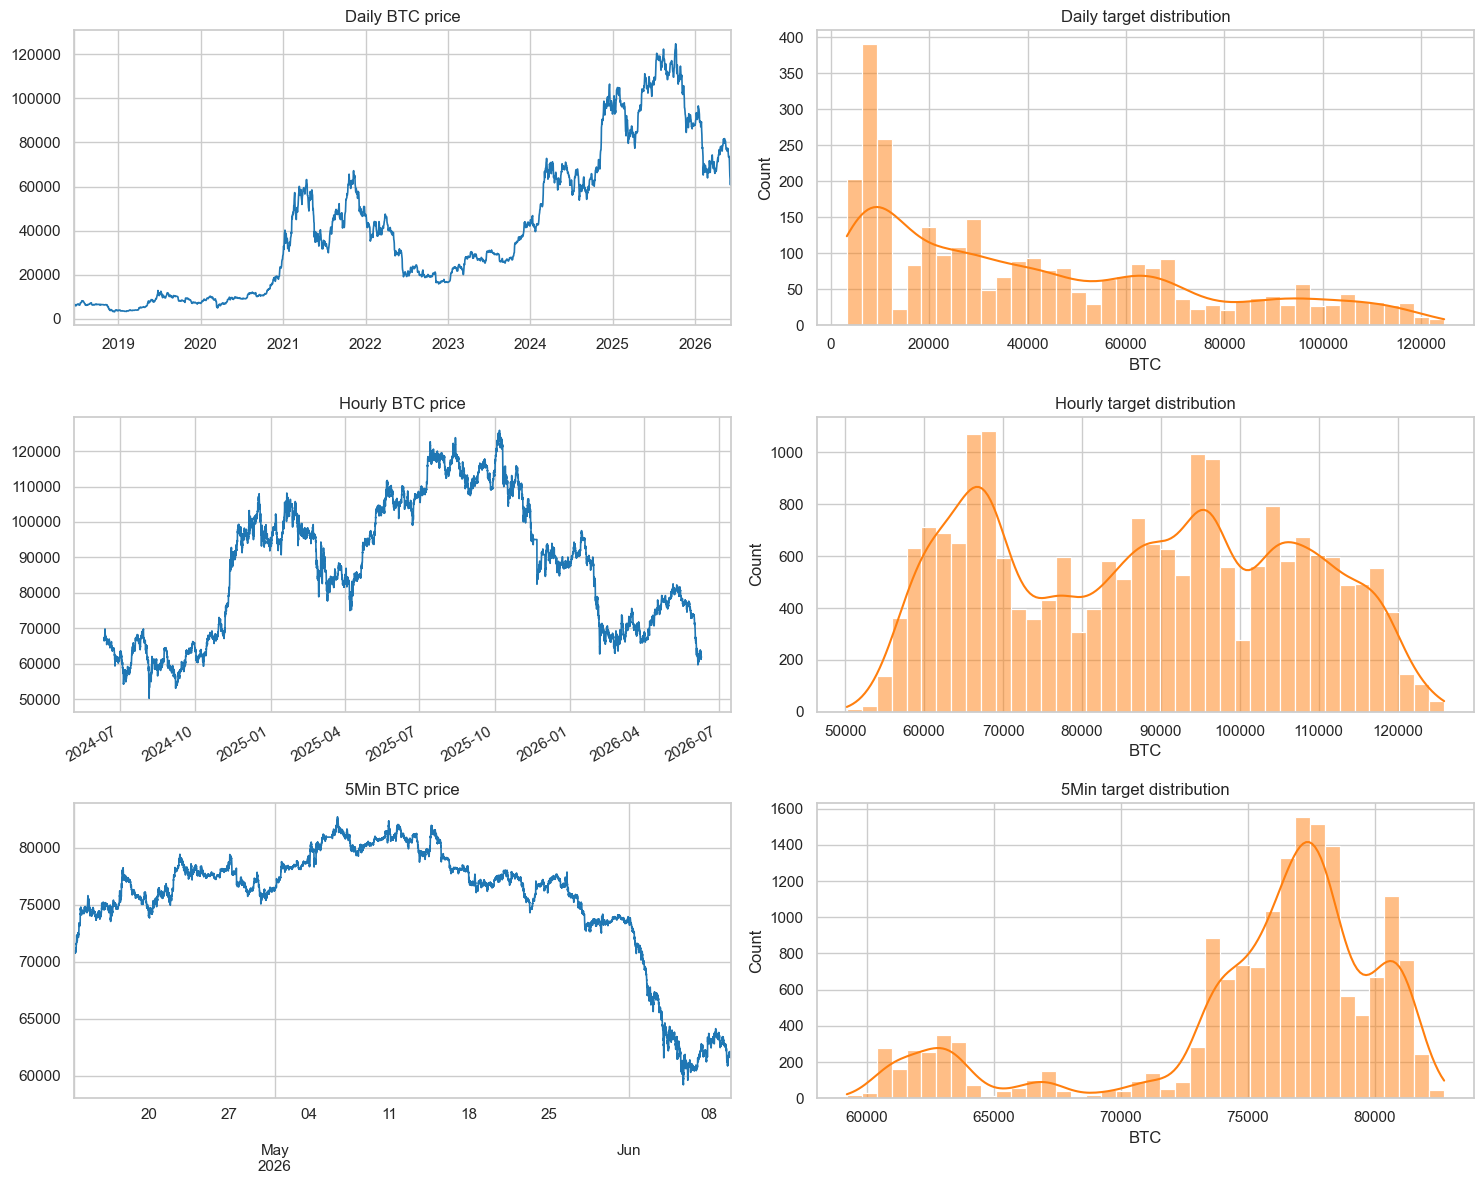

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
for row, (frequency, df) in enumerate(datasets.items()):
    df['BTC'].plot(ax=axes[row, 0], color='tab:blue', linewidth=1.2)
    axes[row, 0].set_title(f'{frequency.title()} BTC price')
    axes[row, 0].set_xlabel('')
    sns.histplot(df['BTC'], bins=40, kde=True, ax=axes[row, 1], color='tab:orange')
    axes[row, 1].set_title(f'{frequency.title()} target distribution')
plt.tight_layout()
plt.show()

### Missing Values and Outliers

The consolidated files have no missing values. The modeling pipeline still includes median imputation to make the workflow robust to future data refreshes. Outliers are handled inside the training pipeline by clipping numeric features to train-fitted 1st and 99th percentiles before robust scaling.


In [14]:
def iqr_outlier_count(frame):
    numeric = frame.select_dtypes(include=[np.number])
    q1 = numeric.quantile(0.25)
    q3 = numeric.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = numeric.lt(lower, axis=1) | numeric.gt(upper, axis=1)
    return mask.sum().sort_values(ascending=False)

missing_table = pd.DataFrame({
    frequency: df.isna().sum() for frequency, df in datasets.items()
}).fillna(0).astype(int)

display(missing_table.sum().rename('missing_values_by_frequency').to_frame())

outlier_rows = []
for frequency, df in datasets.items():
    counts = iqr_outlier_count(df).head(10)
    for feature, count in counts.items():
        outlier_rows.append({'frequency': frequency, 'feature': feature, 'IQR_outlier_count': int(count)})

display(pd.DataFrame(outlier_rows))


,missing_values_by_frequency
daily,0
hourly,0
5min,0


,frequency,feature,IQR_outlier_count
0,daily,Tether,604
1,daily,Initial_Jobless_Claims,581
2,daily,Unemployment_Rate,456
3,daily,XRP,411
4,daily,Platinum_Future,365
5,daily,Gold_Future,344
6,daily,MACD,323
7,daily,MicroStrategy,282
8,daily,TRON,272
9,daily,Natural_Gas_Future,271


## Methodology

The complete pipeline is:

1. Load frozen datasets (Daily, Hourly, 5-minute) and validate size, period, missing values, and feature groups.
2. Convert the task to one-step-ahead forecasting: features at `t` predict `BTC` at `t+1`.
3. Use time-based train/test splits only. No shuffling is used.
4. Use a fixed shortlist of the strongest train-period predictors per frequency (`TOP_FEATURES`), pre-computed once from train-only absolute correlations with the next-period target.
5. Fit preprocessing only on training data: median imputation, 1/99 percentile clipping, robust scaling.
6. Train two baselines (Naive last value, Moving average), four Gradient Boosting variants (HistGradientBoosting, LightGBM, XGBoost, CatBoost), and four neural sequence architectures (LSTM, GRU, Stacked LSTM, CNN-LSTM, all built with `CryptoNet`).
7. Compare models by MAE, RMSE, SMAPE, MASE, and train/test gap; select the best Gradient Boosting model per frequency (`best_gb`).
8. Interpret `best_gb` with permutation importance and SHAP, and the NN models with gradient-based feature attribution.
9. Analyze residuals and compare model behavior during normal periods versus sharp BTC growth/drop periods.

This setup directly targets the thesis comparison: **Gradient Boosting ensembles vs. Neural Networks**, evaluated at Daily, Hourly, and 5-minute granularities, with feature importance and shock-period error analysis as the basis for interpretation.


In [15]:
import sys
sys.path.append(str(PROJECT_DIR))

from ml_models import (
    CryptoNetRegressor, _sample_crypto_hparams, run_optuna_study,
    set_global_seed, DEVICE,
)
set_global_seed(RANDOM_STATE)


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    ratio = np.divide(np.abs(y_true - y_pred), denominator, out=np.zeros_like(denominator), where=denominator != 0)
    return float(np.mean(ratio))


def mase(y_true, y_pred, y_train):
    y_train = np.asarray(y_train, dtype=float)
    scale = np.mean(np.abs(np.diff(y_train)))
    if scale == 0 or np.isnan(scale):
        return np.nan
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale)


def regression_metrics(y_true, y_pred, y_train):
    frame = pd.concat([
        pd.Series(y_true, name='true'),
        pd.Series(y_pred, name='pred')
    ], axis=1).dropna()
    if frame.empty:
        return {'MAE': np.nan, 'RMSE': np.nan, 'SMAPE': np.nan, 'MASE': np.nan}
    return {
        'MAE': mean_absolute_error(frame['true'], frame['pred']),
        'RMSE': np.sqrt(mean_squared_error(frame['true'], frame['pred'])),
        'SMAPE': 100 * smape(frame['true'], frame['pred']),
        'MASE': mase(frame['true'], frame['pred'], y_train),
    }


class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanquantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)


def make_preprocessed_model(model, scale=True):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('clipper', QuantileClipper(lower=0.01, upper=0.99)),
    ]
    if scale:
        steps.append(('scaler', RobustScaler()))
    steps.append(('model', model))
    return Pipeline(steps)


SMAPE_SCORER = make_scorer(smape, greater_is_better=False)


In [16]:
# Hardcoded configuration: feature shortlists and model hyperparameters.
#
# TOP_FEATURES were produced once by running select_top_features(X_train, y_train,
# cfg['max_features']) on the train-only split for each frequency (Pearson |corr|
# with the next-period BTC target). They are used here as the initial candidate
# feature pool for the walk-forward top-k selection (not as a fixed shortlist).
TOP_FEATURES = {
    'daily': [
        'BTC_lag1', 'BTC_mean5', 'BTC_lag2', 'BTC_lag5', 'BTC_lag10',
        'SPDR_Communications', 'TRON', 'SPDR_Financials', 'S&P_500', 'Invesco_QQQ',
        'NASDAQ_100', 'SPDR_Industrials', 'Meta', 'VanEck_Semiconductor_ETF', 'MicroStrategy',
        'SPDR_Consumer_Discretionary', 'Dow_Jones', 'SPDR_Tech', 'Google', 'NVIDIA',
        'Gold_Future', 'Microsoft', 'iShares_Semiconductor_ETF', 'Amazon', 'Silver_Future',
        'XRP', 'ATR', 'Apple', 'ETH', 'year',
    ],
    'hourly': [
        'BTC_lag1', 'BTC_mean5', 'BTC_lag2', 'BTC_lag5', 'BTC_lag10',
        'OBV', 'XRP', 'TRON', 'Stellar', 'ARK_NextGen_Internet_ETF',
        'Meta', 'SPDR_Financials', 'MicroStrategy', 'Litecoin', 'SPDR_Communications',
        'ARKK_ETF', 'SPDR_Consumer_Discretionary', 'Adobe', 'Amazon', 'Cardano',
        'SPDR_Industrials', 'Chainlink', 'Tesla', 'Bitcoin_Cash', 'SPDR_HealthCare',
    ],
    '5min': [
        'BTC_lag1', 'BTC_mean5', 'BTC_lag2', 'BTC_lag5', 'BTC_lag10',
        'MicroStrategy', 'Cardano', 'Dogecoin', 'Chainlink', 'Ethereum_Classic',
        'Litecoin', 'AUD/USD', 'USD/JPY', 'Amazon', 'XRP',
        'SPDR_HealthCare', 'Google', 'USD/CAD', 'OBV', 'Brent_Oil_Future',
    ],
}

# Gradient boosting hyperparameters (structural params fixed; lr/n_est tuned per fold by Optuna).
GB_HYPERPARAMS = {
    'HistGradientBoosting': dict(
        max_iter=260, learning_rate=0.05, l2_regularization=0.05, random_state=RANDOM_STATE,
    ),
    'LightGBM': dict(
        n_estimators=320, learning_rate=0.03, num_leaves=31, min_child_samples=20,
        subsample=0.85, colsample_bytree=0.85, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
    'XGBoost': dict(
        objective='reg:squarederror', n_estimators=320, learning_rate=0.03, max_depth=3,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0, random_state=RANDOM_STATE, n_jobs=-1,
    ),
    'CatBoost': dict(
        iterations=320, learning_rate=0.03, depth=6, l2_leaf_reg=3.0,
        random_state=RANDOM_STATE, verbose=False,
    ),
}

# Sequence-model (CryptoNet) per-frequency settings.
NN_CONFIG = {
    'daily':  {'window_size': 10, 'epochs': 20, 'batch_size': 16},
    'hourly': {'window_size': 24, 'epochs': 15, 'batch_size': 32},
    '5min':   {'window_size': 24, 'epochs': 15, 'batch_size': 64},
}
NN_ARCHITECTURES = ['LSTM', 'GRU', 'StackedLSTM', 'CNN_LSTM']
NN_OPTUNA_TRIALS = 5  # trials in Phase-2 static-split smoke test only

# Walk-forward split configuration per frequency.
# Daily  : expanding window (5 folds, first 50% of rows = initial train).
# Hourly : rolling window, ~125 days train / ~25 days test per fold.
# 5-min  : rolling window, ~8 days train  / ~2 days test per fold.
# Optuna retunes every model on every fold with WF_OPTUNA_TRIALS trials.
SPLIT_CONFIG = {
    'daily':  {'type': 'expanding', 'n_splits': 5, 'min_train_frac': 0.5},
    'hourly': {'type': 'rolling',   'n_splits': 5, 'train_size': 3000, 'test_size': 600},
    '5min':   {'type': 'rolling',   'n_splits': 5, 'train_size': 2400, 'test_size': 600},
}
WF_OPTUNA_TRIALS = 5
WF_TOP_K = 15   # features retained per fold via |Pearson| ranking on train fold only

# Annualisation constant for Sharpe ratio in backtest_summary
PERIODS_PER_YEAR = {'daily': 252, 'hourly': 8760, '5min': 105120}


In [17]:
def make_supervised_frame(df, target_col='BTC', horizon=1):
    if horizon < 1:
        raise ValueError('horizon must be at least 1')
    target_index = df.index[horizon:]
    X = df.drop(columns=[target_col]).iloc[:-horizon].copy()
    X.index = target_index
    y = pd.Series(df[target_col].iloc[horizon:].to_numpy(), index=target_index, name=target_col)
    return X, y


def make_baselines(df, y_index, target_col='BTC', horizon=1, ma_window=7):
    target = df[target_col]
    baselines = pd.DataFrame(index=y_index)
    baselines['Naive last value'] = target.shift(horizon).loc[y_index]
    baselines['Moving average'] = target.shift(horizon).rolling(ma_window, min_periods=1).mean().loc[y_index]
    return baselines


def resolve_test_size(configured_test_size, n_rows):
    if isinstance(configured_test_size, float):
        return int(round(n_rows * configured_test_size))
    return int(configured_test_size)


def time_split(X, y, test_size):
    if test_size <= 0 or test_size >= len(y):
        raise ValueError(f'invalid test_size={test_size} for n={len(y)}')
    return X.iloc[:-test_size], X.iloc[-test_size:], y.iloc[:-test_size], y.iloc[-test_size:]


def make_seq_frames(df, target_col, feature_cols, test_size, window_size):
    """Train/test frames for CryptoNetRegressor.

    `seq_train_df` ends exactly where the GB train split ends; `seq_test_df`
    is prefixed with `window_size` rows of train history so that
    `CryptoNetRegressor.predict` can build a full window for the first test
    timestamp and its predictions land on the same index as `y_test`.
    """
    seq_full = df[feature_cols + [target_col]]
    train_end = len(seq_full) - test_size
    return seq_full.iloc[:train_end], seq_full.iloc[train_end - window_size:]


prepared = OrderedDict()
for frequency, cfg in DATA_CONFIG.items():
    X, y = make_supervised_frame(datasets[frequency], horizon=cfg['horizon'])
    baselines = make_baselines(
        datasets[frequency],
        y.index,
        horizon=cfg['horizon'],
        ma_window=cfg['ma_window'],
    )
    test_size = resolve_test_size(cfg['test_size'], len(y))
    X_train, X_test, y_train, y_test = time_split(X, y, test_size)
    selected_features = TOP_FEATURES[frequency]

    window_size = NN_CONFIG[frequency]['window_size']
    seq_train_df, seq_test_df = make_seq_frames(
        datasets[frequency], 'BTC', selected_features, test_size, window_size
    )

    prepared[frequency] = {
        'X': X,
        'y': y,
        'baselines': baselines,
        'test_size': test_size,
        'X_train': X_train[selected_features],
        'X_test': X_test[selected_features],
        'y_train': y_train,
        'y_test': y_test,
        'selected_features': selected_features,
        'seq': {'train': seq_train_df, 'test': seq_test_df},
    }

split_summary = pd.DataFrame([
    {
        'frequency': frequency,
        'train_rows': len(data['y_train']),
        'test_rows': len(data['y_test']),
        'selected_features': len(data['selected_features']),
        'test_start': data['y_test'].index.min(),
        'test_end': data['y_test'].index.max(),
    }
    for frequency, data in prepared.items()
])

feature_table = pd.DataFrame([
    {'frequency': frequency, 'rank': rank, 'feature': feature}
    for frequency, data in prepared.items()
    for rank, feature in enumerate(data['selected_features'], start=1)
])

display(split_summary)
display(feature_table)


,frequency,train_rows,test_rows,selected_features,test_start,test_end
0,daily,2695,216,30,2025-11-06 00:00:00,2026-06-09 00:00:00
1,hourly,16737,4184,25,2026-01-15 14:30:00,2026-06-09 23:00:00
2,5min,13270,3318,20,2026-05-29 11:30:00,2026-06-09 23:55:00


,frequency,rank,feature
0,daily,1,BTC_lag1
1,daily,2,BTC_mean5
2,daily,3,BTC_lag2
3,daily,4,BTC_lag5
4,daily,5,BTC_lag10
...,...,...,...
70,5min,16,SPDR_HealthCare
71,5min,17,Google
72,5min,18,USD/CAD
73,5min,19,OBV


## Experiment Setup and Results

All models are evaluated on the same time-based splits per frequency. Gradient Boosting and baseline models use a fixed train-only feature shortlist (`TOP_FEATURES`) and hardcoded hyperparameters (`GB_HYPERPARAMS`). Each of the four NN architectures (LSTM, GRU, Stacked LSTM, CNN-LSTM) uses a windowed sequence representation (`NN_CONFIG`), with hyperparameters chosen per architecture/frequency by a small Optuna search (`NN_OPTUNA_TRIALS` trials), and train-only `RobustScaler` fits for both the BTC sequence and the exogenous features. Baselines do not use future observations. All scalers, imputers, and clipping bounds are fit on training data only.


In [18]:
def build_model_specs():
    """Gradient boosting candidates only, with hardcoded hyperparameters (Block 2)."""
    specs = OrderedDict()

    specs['HistGradientBoosting'] = make_preprocessed_model(
        HistGradientBoostingRegressor(**GB_HYPERPARAMS['HistGradientBoosting']),
        scale=False,
    )

    if HAS_LIGHTGBM:
        specs['LightGBM'] = make_preprocessed_model(
            LGBMRegressor(**GB_HYPERPARAMS['LightGBM']),
            scale=False,
        )

    if HAS_XGBOOST:
        specs['XGBoost'] = make_preprocessed_model(
            XGBRegressor(**GB_HYPERPARAMS['XGBoost']),
            scale=False,
        )

    if HAS_CATBOOST:
        specs['CatBoost'] = make_preprocessed_model(
            CatBoostRegressor(**GB_HYPERPARAMS['CatBoost']),
            scale=False,
        )

    return specs


def train_nn_model(frequency, arch, data, n_trials=NN_OPTUNA_TRIALS, seed=RANDOM_STATE):
    """Optuna search + final fit/predict for one CryptoNet architecture.

    Each trial fits a fresh `CryptoNetRegressor` on `seq['train']` (which
    internally splits off a `val_frac` validation tail - see
    `CryptoNetRegressor.fit`) and is scored by that trial's validation SMAPE
    (`best_val_smape_`). The winning hyperparameters are refit once on the
    full `seq['train']` frame before predicting on `seq['test']`.
    """
    cfg = NN_CONFIG[frequency]
    window_size = cfg['window_size']
    feature_cols = data['selected_features']
    seq_train_df = data['seq']['train']
    seq_test_df = data['seq']['test']

    def objective(trial):
        hp = _sample_crypto_hparams(trial, arch, window_size)
        lr = hp.pop('learning_rate')
        reg = CryptoNetRegressor(
            arch=arch, target_col='BTC', feature_cols=feature_cols, window_size=window_size,
            hp=hp, lr=lr, epochs=cfg['epochs'], batch_size=cfg['batch_size'], patience=5, seed=seed,
        )
        reg.fit(seq_train_df)
        return reg.best_val_smape_

    study = run_optuna_study(
        objective, direction='minimize', n_trials=n_trials, seed=seed,
        study_name=f'{frequency}_{arch}',
    )

    best_params = dict(study.best_params)
    lr = best_params.pop('learning_rate')
    reg = CryptoNetRegressor(
        arch=arch, target_col='BTC', feature_cols=feature_cols, window_size=window_size,
        hp=best_params, lr=lr, epochs=cfg['epochs'], batch_size=cfg['batch_size'], patience=5, seed=seed,
    )
    reg.fit(seq_train_df)

    train_pred = reg.predict(seq_train_df)
    test_pred = reg.predict(seq_test_df)
    return train_pred, test_pred, reg


In [20]:
import time as _time
from sklearn.base import clone

from walk_forward import (
    expanding_window_splits, rolling_window_splits, run_walk_forward,
)
from backtest import simulate_strategy, buy_and_hold, backtest_summary


def _family(name):
    if any(a in name for a in ('LSTM', 'GRU', 'CNN_LSTM', 'StackedLSTM')):
        return 'NN'
    if name in ('Naive last value', 'Moving average'):
        return 'baseline'
    return 'GB'


def _get_splits(frequency, cfg, n):
    if cfg['type'] == 'expanding':
        return expanding_window_splits(n, cfg['n_splits'], cfg['min_train_frac'])
    return rolling_window_splits(n, cfg['train_size'], cfg['test_size'], n_splits=cfg['n_splits'])


def make_gb_factory(model_template):
    """Return a zero-arg callable that produces a fresh clone of model_template."""
    def factory():
        return clone(model_template)
    return factory


# Walk-forward containers
wf_metrics_all = {}  # frequency -> concat metrics_df across all models
wf_oof_all = {}      # frequency -> concat oof_df across all models

t_wf_start = _time.time()

for frequency, data in prepared.items():
    print(f'\n=== Walk-forward: {frequency} ===')

    _feat_cols = [c for c in datasets[frequency].columns if c != 'BTC']
    df_freq = datasets[frequency].copy()
    df_freq[_feat_cols] = df_freq[_feat_cols].shift(1)
    df_freq = df_freq.dropna()

    n = len(df_freq)
    cfg = SPLIT_CONFIG[frequency]
    splits = _get_splits(frequency, cfg, n)
    nn_cfg = NN_CONFIG[frequency]
    feat_pool = TOP_FEATURES[frequency]  # candidate feature pool for top-k selection

    freq_metrics_list = []
    freq_oof_list = []

    # 1. Gradient Boosting models
    for gb_name, gb_model_tpl in build_model_specs().items():
        print(f'  GB {gb_name}...', end=' ', flush=True)
        t0 = _time.time()
        mdf, odf = run_walk_forward(
            model_family='GB', model_name=gb_name,
            df=df_freq, target_col='BTC', all_feature_cols=feat_pool,
            splits=splits, top_k=min(WF_TOP_K, len(feat_pool)),
            optuna_n_trials=WF_OPTUNA_TRIALS,
            gb_model_factory=make_gb_factory(gb_model_tpl),
            seed=RANDOM_STATE,
        )
        print(f'{_time.time()-t0:.0f}s  mean SMAPE={mdf["SMAPE"].mean():.4f}')
        freq_metrics_list.append(mdf)
        freq_oof_list.append(odf)

    # 2. NN architectures
    for arch in NN_ARCHITECTURES:
        model_name = f'{arch} (sequence NN)'
        print(f'  NN {arch}...', end=' ', flush=True)
        t0 = _time.time()
        mdf, odf = run_walk_forward(
            model_family='NN', model_name=model_name,
            df=df_freq, target_col='BTC', all_feature_cols=feat_pool,
            splits=splits, top_k=min(WF_TOP_K, len(feat_pool)),
            optuna_n_trials=WF_OPTUNA_TRIALS,
            nn_config=nn_cfg,
            seed=RANDOM_STATE,
        )
        print(f'{_time.time()-t0:.0f}s  mean SMAPE={mdf["SMAPE"].mean():.4f}')
        freq_metrics_list.append(mdf)
        freq_oof_list.append(odf)

    # 3. Baselines on OOF fold windows
    for fold_idx, (train_idx, test_idx) in enumerate(splits):
        prices = df_freq['BTC'].iloc[test_idx]
        naive_pred = df_freq['BTC'].shift(1).iloc[test_idx]
        ma_window = DATA_CONFIG[frequency]['ma_window']
        ma_pred = df_freq['BTC'].shift(1).rolling(ma_window, min_periods=1).mean().iloc[test_idx]
        for bname, bpred in (('Naive last value', naive_pred), ('Moving average', ma_pred)):
            from ml_models import compute_metrics
            y_tr = df_freq['BTC'].iloc[train_idx].to_numpy(dtype=float)
            m = compute_metrics(prices.to_numpy(dtype=float), bpred.to_numpy(dtype=float), y_tr)
            freq_metrics_list.append(pd.DataFrame([{
                'fold': fold_idx, 'model': bname,
                'MAE': m['mae'], 'RMSE': m['rmse'], 'SMAPE': m['smape'], 'MASE': m['mase'],
                'n_train': len(train_idx), 'n_test': len(test_idx),
            }]))
            freq_oof_list.append(pd.DataFrame({
                'timestamp': prices.index, 'actual': prices.values,
                'predicted': bpred.values, 'fold': fold_idx, 'model': bname,
            }))

    wf_metrics_all[frequency] = pd.concat(freq_metrics_list, ignore_index=True)
    wf_oof_all[frequency] = pd.concat(freq_oof_list, ignore_index=True)

print(f'\nTotal walk-forward time: {_time.time()-t_wf_start:.0f}s')

# Aggregate: mean metrics across folds
agg_frames = []
for freq, mdf in wf_metrics_all.items():
    agg = mdf.groupby('model')[['MAE', 'RMSE', 'SMAPE', 'MASE']].mean().reset_index()
    agg['frequency'] = freq
    agg['family'] = agg['model'].apply(_family)
    agg_frames.append(agg)
wf_agg = pd.concat(agg_frames, ignore_index=True)

# Best GB / NN per frequency by mean OOF SMAPE
_gb_names = set(build_model_specs().keys())
_nn_names = {f'{a} (sequence NN)' for a in NN_ARCHITECTURES}
best_gb = (wf_agg[wf_agg['model'].isin(_gb_names)]
           .loc[lambda d: d.groupby('frequency')['SMAPE'].transform('min') == d['SMAPE']]
           .reset_index(drop=True))
best_nn = (wf_agg[wf_agg['model'].isin(_nn_names)]
           .loc[lambda d: d.groupby('frequency')['SMAPE'].transform('min') == d['SMAPE']]
           .reset_index(drop=True))

# Refit best GB on last fold's training data (for permutation importance / SHAP in Phase 4)
refit_gb = {}  # frequency -> model_name -> fitted Pipeline
for _, row in best_gb.iterrows():
    freq = row['frequency']
    mname = row['model']
    n = len(datasets[freq])
    last_train_idx = _get_splits(freq, SPLIT_CONFIG[freq], n)[-1][0]
    X_last = datasets[freq][TOP_FEATURES[freq]].iloc[last_train_idx]
    y_last = datasets[freq]['BTC'].iloc[last_train_idx]
    m = clone(build_model_specs()[mname])
    m.fit(X_last, y_last)
    refit_gb.setdefault(freq, {})[mname] = m

# Refit best NN on last fold's seq_train_df (for gradient attribution)
refit_nn = {}  # frequency -> model_name -> fitted CryptoNetRegressor
for _, row in best_nn.iterrows():
    freq = row['frequency']
    mname = row['model']
    arch = mname.split()[0]
    nn_cfg = NN_CONFIG[freq]
    n = len(datasets[freq])
    last_train_idx = _get_splits(freq, SPLIT_CONFIG[freq], n)[-1][0]
    seq_cols = TOP_FEATURES[freq] + ['BTC']
    seq_train_df = datasets[freq][seq_cols].iloc[last_train_idx]
    # Use best params from last static-split Optuna search as an approximation
    # (Phase 4 will replace this with the last WF fold's Optuna best params)
    default_hp = {'gru_units': 64, 'gru_drop': 0.2, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2}
    hp_map = {
        'LSTM': {'lstm_units': 64, 'lstm_drop': 0.2, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
        'GRU': {'gru_units': 64, 'gru_drop': 0.2, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
        'StackedLSTM': {'stacked_layers': 2, 'stack_units_0': 64, 'stack_drop_0': 0.2, 'stack_units_1': 64, 'stack_drop_1': 0.2, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
        'CNN_LSTM': {'cnn_kernel': 3, 'pool_size': 2, 'cnn_filters': 32, 'cnn_drop': 0.2, 'cnn_lstm_units': 64, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
    }
    reg = CryptoNetRegressor(
        arch=arch, target_col='BTC', feature_cols=TOP_FEATURES[freq],
        window_size=nn_cfg['window_size'], hp=hp_map.get(arch, default_hp),
        lr=1e-3, epochs=nn_cfg['epochs'], batch_size=nn_cfg['batch_size'],
        patience=5, seed=RANDOM_STATE,
    )
    reg.fit(seq_train_df)
    refit_nn.setdefault(freq, {})[mname] = reg

# Compatibility layer: populate prediction_store so downstream cells work with OOF predictions
prediction_store = OrderedDict()
for freq, oof_df in wf_oof_all.items():
    prediction_store[freq] = {}
    for model_name, grp in oof_df.groupby('model'):
        grp = grp.sort_values('timestamp')
        fitted_obj = refit_gb.get(freq, {}).get(model_name) or refit_nn.get(freq, {}).get(model_name)
        prediction_store[freq][model_name] = {
            'test_pred': pd.Series(grp['predicted'].values, index=grp['timestamp']),
            'train_pred': pd.Series(dtype=float),
            'model': fitted_obj,
        }

results_df = wf_agg.rename(columns={}).copy()
results_df['train/test gap'] = 0.0
results_df['comment'] = 'Walk-forward OOF mean across folds'



=== Walk-forward: daily ===
  GB HistGradientBoosting... 

50s  mean SMAPE=0.1108
  GB LightGBM... 14s  mean SMAPE=0.1112
  GB XGBoost... 11s  mean SMAPE=0.1062
  GB CatBoost... 39s  mean SMAPE=0.1405
  NN LSTM... 203s  mean SMAPE=0.0241
  NN GRU... 165s  mean SMAPE=0.0281
  NN StackedLSTM... 249s  mean SMAPE=0.0406
  NN CNN_LSTM... 186s  mean SMAPE=0.0812

=== Walk-forward: hourly ===
  GB HistGradientBoosting... 57s  mean SMAPE=0.0429
  GB LightGBM... 16s  mean SMAPE=0.0428
  GB XGBoost... 11s  mean SMAPE=0.0420
  GB CatBoost... 42s  mean SMAPE=0.0503
  NN LSTM... 123s  mean SMAPE=0.0280
  NN GRU... 125s  mean SMAPE=0.0212
  NN StackedLSTM... 183s  mean SMAPE=0.0197
  NN CNN_LSTM... 141s  mean SMAPE=0.0371

=== Walk-forward: 5min ===
  GB HistGradientBoosting... 54s  mean SMAPE=0.0023
  GB LightGBM... 15s  mean SMAPE=0.0022
  GB XGBoost... 11s  mean SMAPE=0.0025
  GB CatBoost... 40s  mean SMAPE=0.0045
  NN LSTM... 60s  mean SMAPE=0.0010
  NN GRU... 57s  mean SMAPE=0.0015
  NN StackedLSTM... 73s  mean SMAPE=0.0026
  NN CNN_LSTM... 59s  mean S

Walk-forward per-fold metrics (all models, all frequencies):

--- daily ---


,fold,model,MAE,RMSE,SMAPE,MASE,n_train,n_test
35,0,CNN_LSTM (sequence NN),2150.94,2413.30,0.09925,4.3501,1455,291
36,1,CNN_LSTM (sequence NN),1511.20,1734.01,0.04763,3.2199,1746,291
37,2,CNN_LSTM (sequence NN),6309.51,7069.17,0.10384,13.8368,2037,291
38,3,CNN_LSTM (sequence NN),11347.17,12430.04,0.11810,21.6996,2328,291
39,4,CNN_LSTM (sequence NN),3200.96,4038.58,0.03719,5.2139,2619,291
15,0,CatBoost,2873.07,3319.94,0.13240,5.8105,1455,291
16,1,CatBoost,1237.97,1556.97,0.04033,2.6377,1746,291
17,2,CatBoost,4176.71,5198.14,0.06720,9.1595,2037,291
18,3,CatBoost,30037.62,31854.79,0.35034,57.4421,2328,291
19,4,CatBoost,9458.53,11125.10,0.11210,15.4065,2619,291



--- hourly ---


,fold,model,MAE,RMSE,SMAPE,MASE,n_train,n_test
35,0,CNN_LSTM (sequence NN),463.06,555.08,0.00729,3.0993,3000,600
36,1,CNN_LSTM (sequence NN),843.59,921.56,0.01236,5.5923,3000,600
37,2,CNN_LSTM (sequence NN),12221.79,14303.50,0.14684,84.2106,3000,600
38,3,CNN_LSTM (sequence NN),905.89,1095.41,0.00921,5.8328,3000,600
39,4,CNN_LSTM (sequence NN),997.78,1381.84,0.01002,5.6035,3000,600
15,0,CatBoost,269.66,367.70,0.00429,1.8048,3000,600
16,1,CatBoost,2598.97,3023.42,0.03843,17.2290,3000,600
17,2,CatBoost,14147.19,16633.09,0.17262,97.4771,3000,600
18,3,CatBoost,1547.79,2091.70,0.01575,9.9658,3000,600
19,4,CatBoost,1978.16,2342.56,0.02024,11.1094,3000,600



--- 5min ---


,fold,model,MAE,RMSE,SMAPE,MASE,n_train,n_test
35,0,CNN_LSTM (sequence NN),407.48,489.60,0.00522,7.4025,2400,600
36,1,CNN_LSTM (sequence NN),441.12,503.76,0.00566,8.1018,2400,600
37,2,CNN_LSTM (sequence NN),87.68,136.30,0.00112,1.8186,2400,600
38,3,CNN_LSTM (sequence NN),93.59,128.19,0.00122,1.9849,2400,600
39,4,CNN_LSTM (sequence NN),99.58,128.32,0.00130,2.3046,2400,600
15,0,CatBoost,1114.25,1243.28,0.01437,20.2423,2400,600
16,1,CatBoost,173.41,197.58,0.00223,3.1849,2400,600
17,2,CatBoost,116.35,170.56,0.00149,2.4131,2400,600
18,3,CatBoost,206.42,257.19,0.00270,4.3781,2400,600
19,4,CatBoost,147.23,197.66,0.00190,3.4075,2400,600




Walk-forward aggregate (mean across folds):


,frequency,model,family,MAE,RMSE,SMAPE,MASE
27,5min,Naive last value,baseline,42.78,64.35,0.00055,0.8663
24,5min,LSTM (sequence NN),NN,78.00,101.82,0.00101,1.5720
26,5min,Moving average,baseline,110.24,159.76,0.00142,2.2303
22,5min,GRU (sequence NN),NN,115.97,141.71,0.00149,2.3068
25,5min,LightGBM,GB,171.77,228.50,0.00221,3.3097
23,5min,HistGradientBoosting,GB,176.46,230.74,0.00227,3.4089
29,5min,XGBoost,GB,197.88,250.41,0.00255,3.7636
28,5min,StackedLSTM (sequence NN),NN,204.42,240.66,0.00263,4.2157
20,5min,CNN_LSTM (sequence NN),NN,225.89,277.23,0.00291,4.3225
21,5min,CatBoost,GB,351.53,413.25,0.00454,6.7252


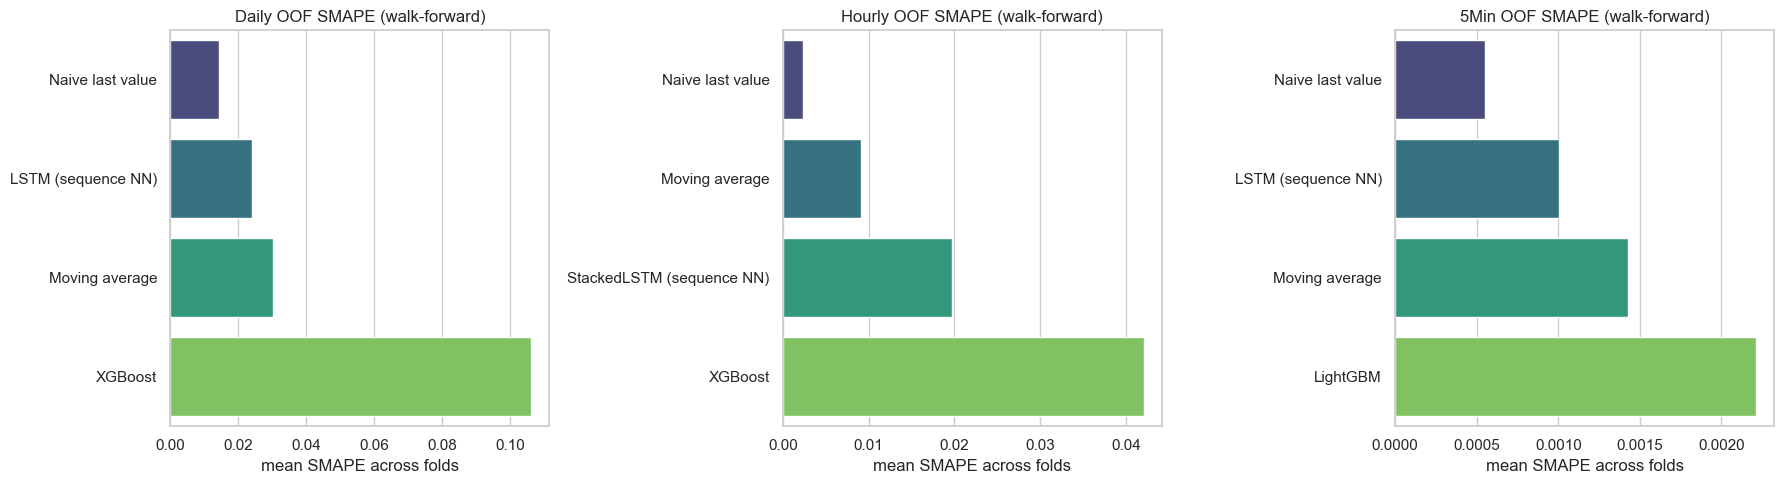

Best models per frequency (walk-forward OOF):


,frequency,model,family,MAE,RMSE,SMAPE,MASE
0,5min,Naive last value,baseline,42.78,64.35,0.00055,0.8663
1,5min,LSTM (sequence NN),NN,78.00,101.82,0.00101,1.5720
2,5min,Moving average,baseline,110.24,159.76,0.00142,2.2303
3,5min,LightGBM,GB,171.77,228.50,0.00221,3.3097
4,daily,Naive last value,baseline,852.19,1180.86,0.01440,1.6408
5,daily,LSTM (sequence NN),NN,1648.00,2042.56,0.02409,3.0909
6,daily,Moving average,baseline,1741.40,2332.84,0.03021,3.3609
7,daily,XGBoost,GB,7837.61,8712.57,0.10616,15.1272
8,hourly,Naive last value,baseline,199.36,317.81,0.00236,1.2774
9,hourly,Moving average,baseline,766.49,1051.31,0.00910,4.9005




Economic backtest (long/flat signal, Binance 0.05% maker fee, 2 bps slippage):

--- daily ---


,model,type,total_return_usd,pnl_usd,total_fees_usd,sharpe,max_drawdown_usd,turnover
1,CNN_LSTM (sequence NN),Buy&Hold,41196.22,41196.22,0.00,0.347,64044.01,0
0,CNN_LSTM (sequence NN),Strategy,-10407.16,-10407.16,7140.25,-0.193,31691.23,73
3,CatBoost,Buy&Hold,41196.22,41196.22,0.00,0.347,64044.01,0
2,CatBoost,Strategy,-29006.30,-29006.30,7052.46,-0.424,45458.54,101
5,GRU (sequence NN),Buy&Hold,41196.22,41196.22,0.00,0.347,64044.01,0
4,GRU (sequence NN),Strategy,20960.03,20960.03,4953.87,0.381,28379.68,49
7,HistGradientBoosting,Buy&Hold,41196.22,41196.22,0.00,0.347,64044.01,0
6,HistGradientBoosting,Strategy,-40643.92,-40643.92,14231.19,-0.603,58677.84,205
9,LSTM (sequence NN),Buy&Hold,41196.22,41196.22,0.00,0.347,64044.01,0
8,LSTM (sequence NN),Strategy,-34598.63,-34598.63,13339.11,-0.385,67217.58,249



--- hourly ---


,model,type,total_return_usd,pnl_usd,total_fees_usd,sharpe,max_drawdown_usd,turnover
21,CNN_LSTM (sequence NN),Buy&Hold,35991.24,35991.24,0.00,3.382,16131.10,0
20,CNN_LSTM (sequence NN),Strategy,-18010.24,-18010.24,16465.36,-3.137,24210.90,138
23,CatBoost,Buy&Hold,35991.24,35991.24,0.00,3.382,16131.10,0
22,CatBoost,Strategy,-5763.37,-5763.37,18133.20,-1.316,13316.16,178
25,GRU (sequence NN),Buy&Hold,35991.24,35991.24,0.00,3.382,16131.10,0
24,GRU (sequence NN),Strategy,-7033.45,-7033.45,12520.91,-2.508,8708.58,124
27,HistGradientBoosting,Buy&Hold,35991.24,35991.24,0.00,3.382,16131.10,0
26,HistGradientBoosting,Strategy,-31353.66,-31353.66,31713.80,-5.259,33009.88,284
29,LSTM (sequence NN),Buy&Hold,35991.24,35991.24,0.00,3.382,16131.10,0
28,LSTM (sequence NN),Strategy,-28476.66,-28476.66,32680.42,-4.318,35142.73,293



--- 5min ---


,model,type,total_return_usd,pnl_usd,total_fees_usd,sharpe,max_drawdown_usd,turnover
41,CNN_LSTM (sequence NN),Buy&Hold,2669.92,2669.92,0.00,4.443,4358.03,0
40,CNN_LSTM (sequence NN),Strategy,-36960.64,-36960.64,31713.41,-75.167,36960.64,294
43,CatBoost,Buy&Hold,2669.92,2669.92,0.00,4.443,4358.03,0
42,CatBoost,Strategy,-28977.99,-28977.99,25715.16,-58.611,28977.99,238
45,GRU (sequence NN),Buy&Hold,2669.92,2669.92,0.00,4.443,4358.03,0
44,GRU (sequence NN),Strategy,-17647.17,-17647.17,15447.47,-42.770,18475.96,144
47,HistGradientBoosting,Buy&Hold,2669.92,2669.92,0.00,4.443,4358.03,0
46,HistGradientBoosting,Strategy,-67107.25,-67107.25,61674.26,-118.520,67107.25,570
49,LSTM (sequence NN),Buy&Hold,2669.92,2669.92,0.00,4.443,4358.03,0
48,LSTM (sequence NN),Strategy,-38375.26,-38375.26,35306.72,-80.159,39941.72,327


In [21]:
# Per-fold metrics table
print('Walk-forward per-fold metrics (all models, all frequencies):')
for freq in wf_metrics_all:
    print(f'\n--- {freq} ---')
    fold_table = (wf_metrics_all[freq]
                  .sort_values(['model', 'fold'])
                  [['fold', 'model', 'MAE', 'RMSE', 'SMAPE', 'MASE', 'n_train', 'n_test']])
    display(fold_table.round({'MAE': 2, 'RMSE': 2, 'SMAPE': 5, 'MASE': 4}))

# Aggregate: mean across folds per model
print('\n\nWalk-forward aggregate (mean across folds):')
agg_display = wf_agg.sort_values(['frequency', 'SMAPE']).copy()
display(agg_display[['frequency', 'model', 'family', 'MAE', 'RMSE', 'SMAPE', 'MASE']]
        .round({'MAE': 2, 'RMSE': 2, 'SMAPE': 5, 'MASE': 4}))

# Headline bar chart: Naive + best GB + best NN per frequency
baseline_agg = wf_agg[wf_agg['family'] == 'baseline']
headline = pd.concat([baseline_agg, best_gb, best_nn]).sort_values(['frequency', 'SMAPE']).reset_index(drop=True)

fig, axes = plt.subplots(1, len(prepared), figsize=(6 * len(prepared), 5), sharey=False)
for ax, frequency in zip(axes, prepared.keys()):
    subset = headline[headline['frequency'] == frequency].sort_values('SMAPE')
    sns.barplot(data=subset, x='SMAPE', y='model', ax=ax, palette='viridis')
    ax.set_title(f'{frequency.title()} OOF SMAPE (walk-forward)')
    ax.set_xlabel('mean SMAPE across folds')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('Best models per frequency (walk-forward OOF):')
display(headline[['frequency', 'model', 'family', 'MAE', 'RMSE', 'SMAPE', 'MASE']].round({'MAE': 2, 'RMSE': 2, 'SMAPE': 5, 'MASE': 4}))

# -------------------------------------------------------
# Economic backtest
# -------------------------------------------------------
print('\n\nEconomic backtest (long/flat signal, Binance 0.05% maker fee, 2 bps slippage):')
econ_frames = []
for freq, oof_df in wf_oof_all.items():
    strat = simulate_strategy(oof_df, fee_rate=0.0005, slippage_bps=2.0)
    bh = buy_and_hold(oof_df)
    ppy = PERIODS_PER_YEAR[freq]
    summary = backtest_summary(strat, bh, periods_per_year=ppy)
    summary['frequency'] = freq
    econ_frames.append(summary)

econ_df = pd.concat(econ_frames, ignore_index=True)

for freq in prepared:
    print(f'\n--- {freq} ---')
    subset = econ_df[econ_df['frequency'] == freq].sort_values(['model', 'type'])
    display(subset[['model', 'type', 'total_return_usd', 'pnl_usd', 'total_fees_usd',
                     'sharpe', 'max_drawdown_usd', 'turnover']]
            .round({'total_return_usd': 2, 'pnl_usd': 2, 'total_fees_usd': 2,
                    'sharpe': 3, 'max_drawdown_usd': 2}))

## Interpretation

Feature importance is computed for the best Gradient Boosting model per frequency using permutation importance (model-agnostic, test segment) and SHAP (`TreeExplainer`, when available). For the GRU, feature importance is approximated with gradient-based attribution (mean absolute gradient of the prediction with respect to each scaled exogenous feature), since SHAP's tree explainer does not apply to a PyTorch model. Comparing the two rankings is the basis for research question 3: do GB and the GRU rely on similar predictive signals?


,frequency,model,feature,importance_mean,importance_std
0,daily,XGBoost,BTC_lag1,11277.6529,320.9317
1,daily,XGBoost,BTC_mean5,2370.9080,85.2728
2,daily,XGBoost,MicroStrategy,833.4456,54.1726
3,daily,XGBoost,BTC_lag2,502.9334,69.9618
4,daily,XGBoost,BTC_lag10,53.5541,11.5113
5,daily,XGBoost,XRP,29.8259,9.4497
6,daily,XGBoost,Microsoft,24.5451,13.5890
7,daily,XGBoost,Amazon,23.3235,6.3016
8,daily,XGBoost,ATR,22.0874,8.9398
9,daily,XGBoost,BTC_lag5,11.8782,10.4438


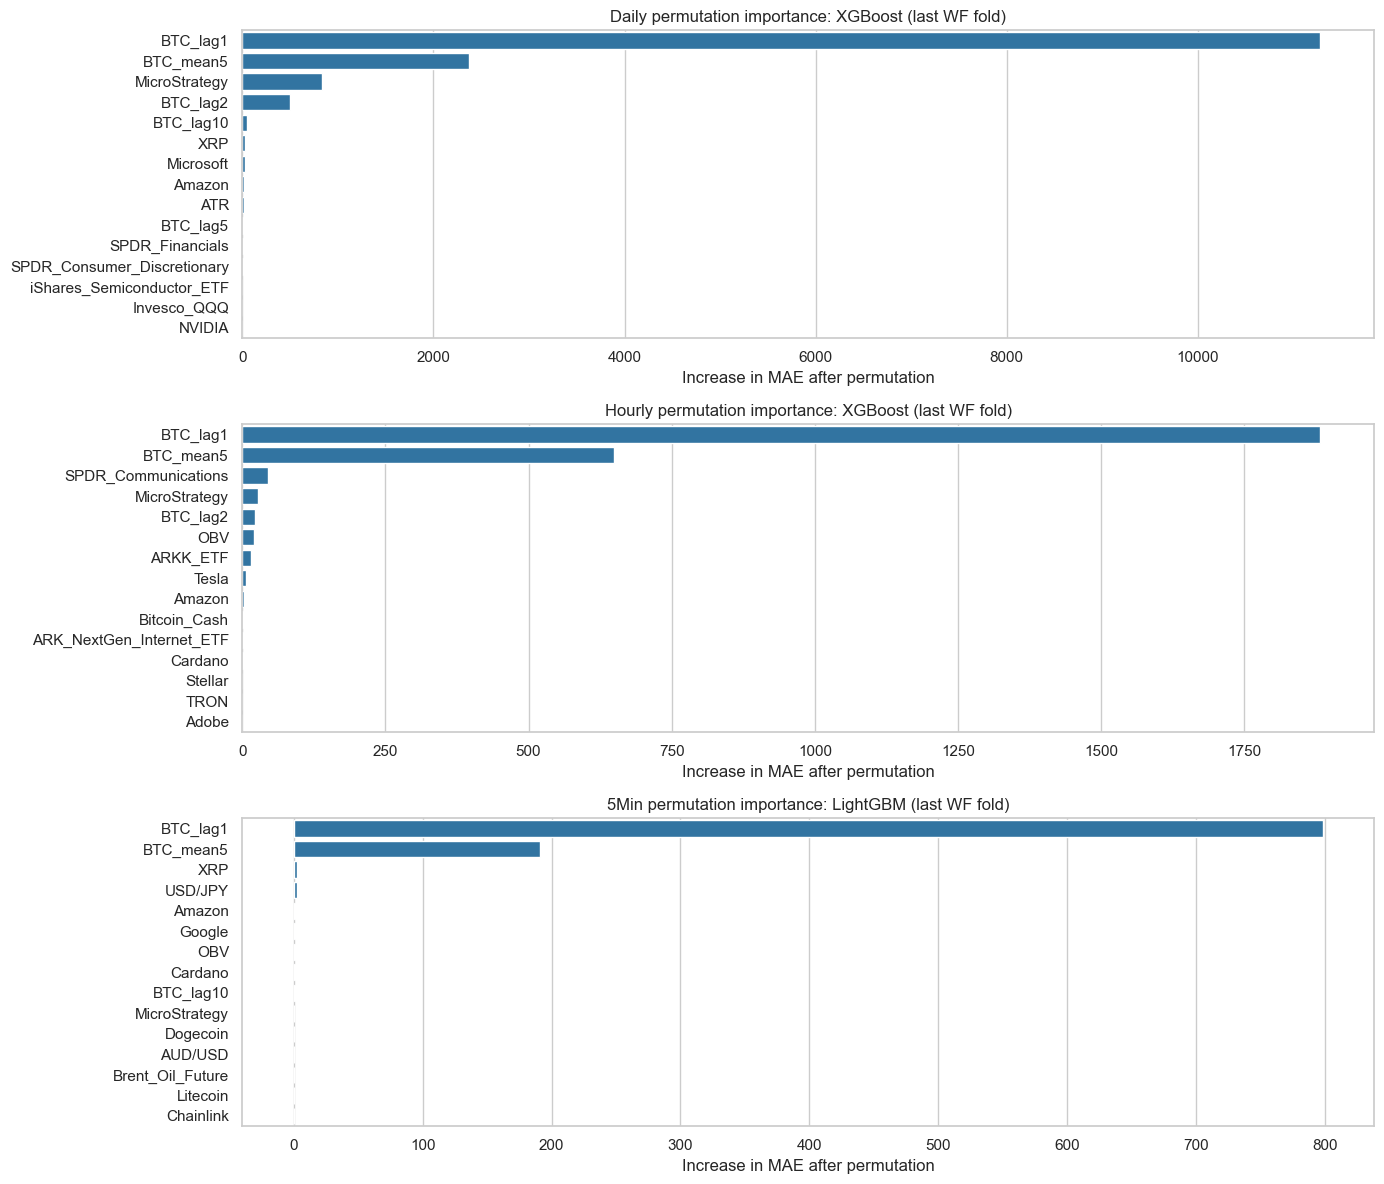

In [22]:
def permutation_importance_table(frequency, model_name, n_repeats=5, top_n=15):
    model = prediction_store[frequency][model_name]['model']
    if model is None or not hasattr(model, 'predict'):
        return pd.DataFrame()
    # Use last walk-forward fold's test data for permutation importance
    n = len(datasets[frequency])
    last_train_idx, last_test_idx = _get_splits(frequency, SPLIT_CONFIG[frequency], n)[-1]
    X_test_last = datasets[frequency][TOP_FEATURES[frequency]].iloc[last_test_idx]
    y_test_last = datasets[frequency]['BTC'].iloc[last_test_idx]
    importance = permutation_importance(
        model,
        X_test_last,
        y_test_last,
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        scoring='neg_mean_absolute_error',
        n_jobs=1,
    )
    table = pd.DataFrame({
        'frequency': frequency,
        'model': model_name,
        'feature': X_test_last.columns,
        'importance_mean': importance.importances_mean,
        'importance_std': importance.importances_std,
    }).sort_values('importance_mean', ascending=False).head(top_n)
    return table

importance_tables = []
for _, row in best_gb.iterrows():
    table = permutation_importance_table(row['frequency'], row['model'])
    if not table.empty:
        importance_tables.append(table)

if importance_tables:
    importance_df = pd.concat(importance_tables, ignore_index=True)
    display(importance_df.round(4))

    fig, axes = plt.subplots(len(importance_tables), 1, figsize=(14, 4 * len(importance_tables)))
    if len(importance_tables) == 1:
        axes = [axes]
    for ax, table in zip(axes, importance_tables):
        sns.barplot(data=table, x='importance_mean', y='feature', ax=ax, color='tab:blue')
        frequency = table['frequency'].iloc[0]
        model_name = table['model'].iloc[0]
        ax.set_title(f'{frequency.title()} permutation importance: {model_name} (last WF fold)')
        ax.set_xlabel('Increase in MAE after permutation')
        ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('No permutation importance table was produced for the selected GB models.')


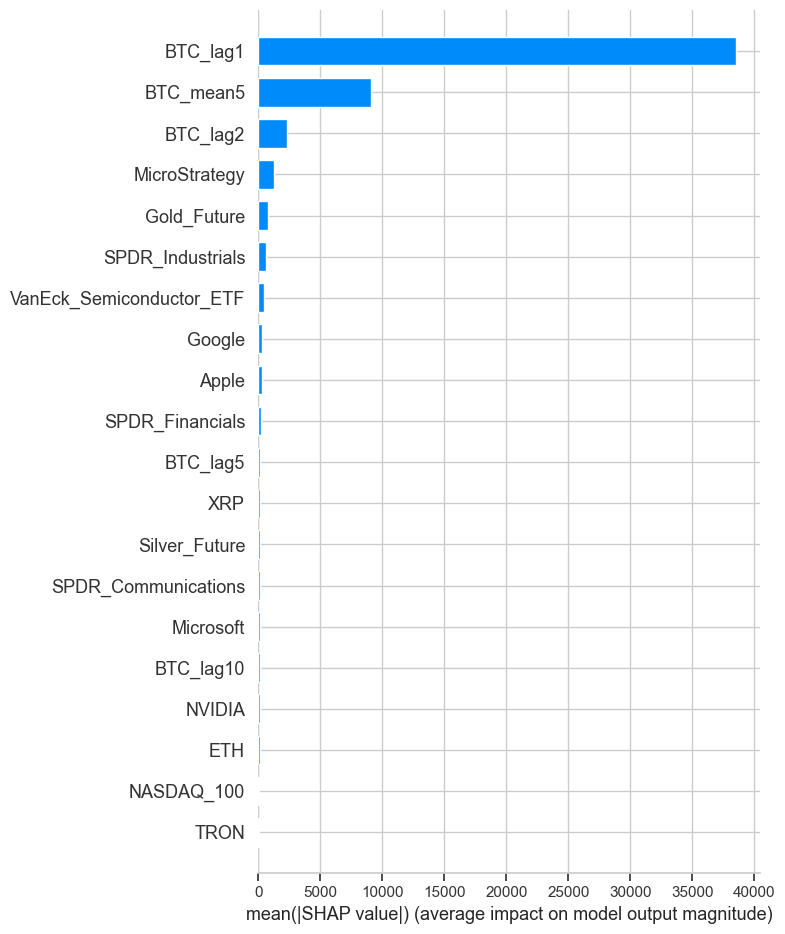

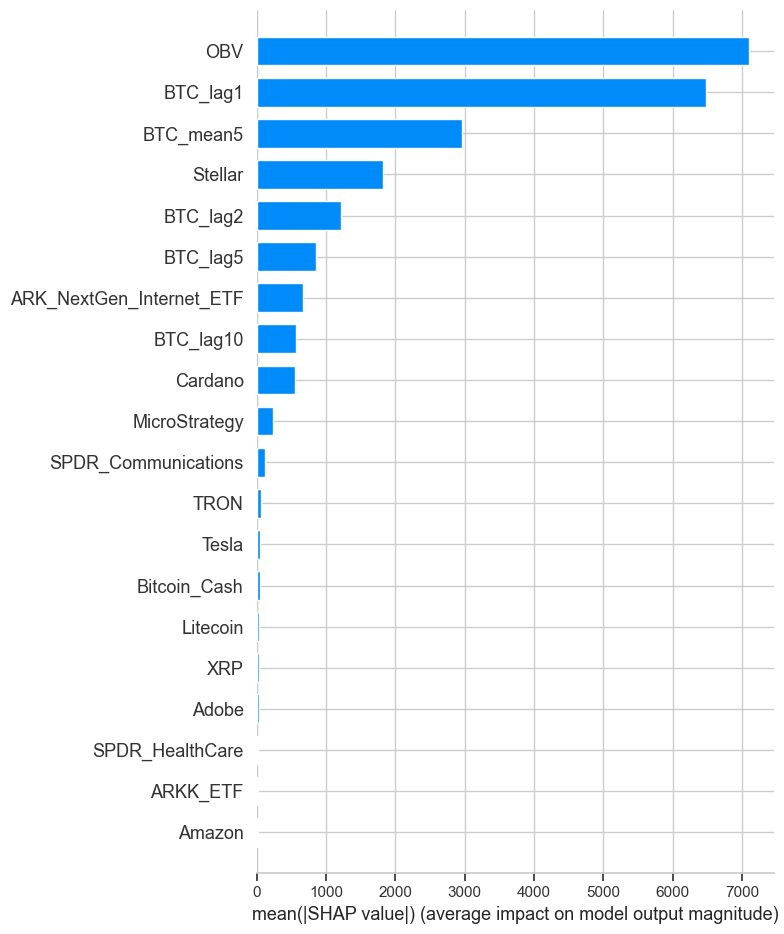

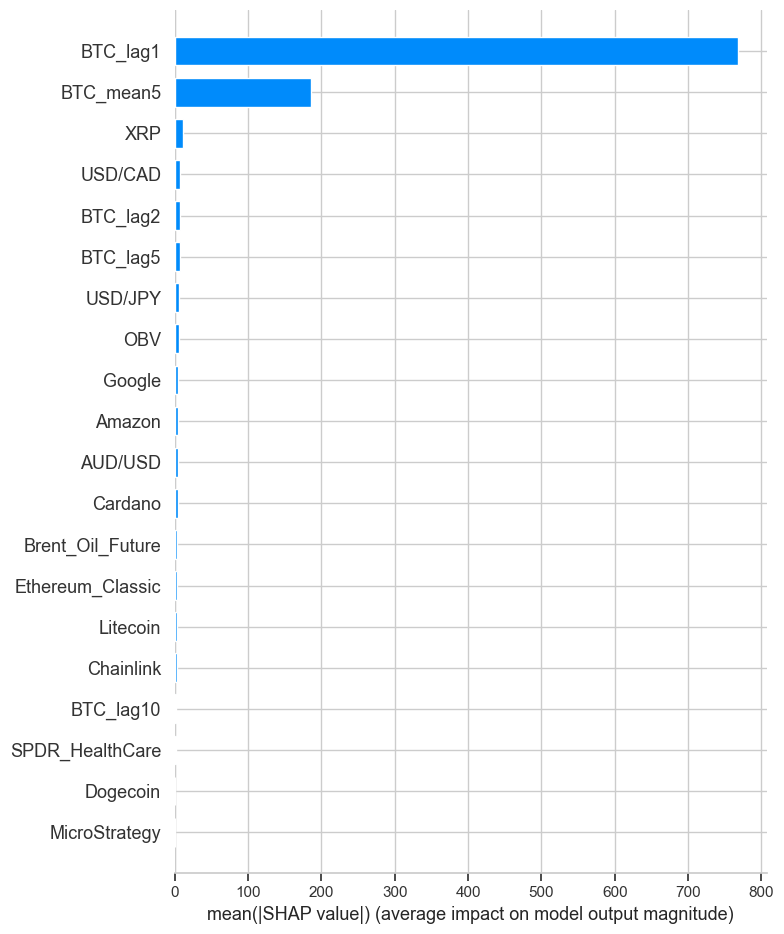

In [23]:
# SHAP interpretation for the best Gradient Boosting model per frequency.
# Uses the refit model (trained on last WF fold's train data) and that fold's test data.
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

if HAS_SHAP:
    for _, row in best_gb.iterrows():
        frequency = row['frequency']
        model_name = row['model']
        model = prediction_store[frequency][model_name]['model']
        if model is None:
            print(f'No refit model for {frequency} {model_name}, skipping SHAP.')
            continue
        # Last WF fold test data (same as permutation importance)
        n = len(datasets[frequency])
        _, last_test_idx = _get_splits(frequency, SPLIT_CONFIG[frequency], n)[-1]
        X_test_last = datasets[frequency][TOP_FEATURES[frequency]].iloc[last_test_idx]
        sample = X_test_last.sample(min(500, len(X_test_last)), random_state=RANDOM_STATE)
        estimator = model.named_steps['model'] if isinstance(model, Pipeline) else model
        transformed = model[:-1].transform(sample) if isinstance(model, Pipeline) else sample
        try:
            explainer = shap.TreeExplainer(estimator)
            shap_values = explainer.shap_values(transformed)
            shap.summary_plot(shap_values, sample, plot_type='bar', show=True)
        except Exception as exc:
            print(f'SHAP failed for {frequency} {model_name}: {exc}')
else:
    print('SHAP is not installed in the active environment; permutation importance above is used as the reproducible interpretation method for the GB models.')


In [24]:
# Captum Integrated Gradients attribution for the best NN per frequency.
# Attributes the exogenous-feature branch of CryptoNet; the BTC-sequence branch
# is held fixed (its values are reused at every interpolation step), isolating
# the marginal contribution of each exogenous feature relative to a zero baseline.
try:
    from captum.attr import IntegratedGradients
    HAS_CAPTUM = True
except ImportError:
    HAS_CAPTUM = False

import torch

nn_attribution_tables = []
for _, row in best_nn.iterrows():
    frequency = row['frequency']
    model_name = row['model']
    reg = prediction_store[frequency][model_name]['model']
    if reg is None or not hasattr(reg, 'model_'):
        print(f'No fitted NN model available for {frequency} {model_name}, skipping.')
        continue

    # Last WF fold test data with window_size history prefix
    n = len(datasets[frequency])
    last_train_idx, last_test_idx = _get_splits(frequency, SPLIT_CONFIG[frequency], n)[-1]
    hist_start = max(0, int(last_train_idx[-1]) + 1 - reg.window_size)
    seq_test_df = datasets[frequency][TOP_FEATURES[frequency] + ['BTC']].iloc[
        hist_start : int(last_test_idx[-1]) + 1
    ]

    X_seq, X_ex, _, _ = reg._make_windows(seq_test_df)
    X_seq_s = reg.scaler_y_.transform(X_seq.reshape(-1, 1)).reshape(X_seq.shape)
    X_ex_s = reg.scaler_x_.transform(X_ex)

    x_seq_t = torch.tensor(X_seq_s, dtype=torch.float32, device=DEVICE)
    x_ex_t = torch.tensor(X_ex_s, dtype=torch.float32, device=DEVICE)

    reg.model_.eval()

    if HAS_CAPTUM:
        # Captum IG: exogenous branch input; BTC sequence branch held fixed per call.
        ig = IntegratedGradients(lambda x_ex: reg.model_(x_seq_t, x_ex))
        attributions, convergence_delta = ig.attribute(
            x_ex_t,
            baselines=torch.zeros_like(x_ex_t),
            return_convergence_delta=True,
        )
        importance = attributions.detach().abs().cpu().numpy().mean(axis=0)
        method_label = 'Captum IntegratedGradients'
    else:
        # Fallback to plain gradient attribution when captum is unavailable
        x_ex_grad = x_ex_t.clone().requires_grad_(True)
        reg.model_(x_seq_t, x_ex_grad).sum().backward()
        importance = x_ex_grad.grad.detach().abs().cpu().numpy().mean(axis=0)
        method_label = 'gradient attribution (backward)'

    feature_names = reg.feature_cols if hasattr(reg, 'feature_cols') and reg.feature_cols else TOP_FEATURES[frequency]
    table = pd.DataFrame({
        'frequency': frequency,
        'model': model_name,
        'feature': feature_names,
        'importance_mean': importance,
        'method': method_label,
    }).sort_values('importance_mean', ascending=False).head(15)
    nn_attribution_tables.append(table)

if nn_attribution_tables:
    nn_attribution_df = pd.concat(nn_attribution_tables, ignore_index=True)
    display(nn_attribution_df.round(4))

    fig, axes = plt.subplots(len(nn_attribution_tables), 1, figsize=(14, 4 * len(nn_attribution_tables)))
    if len(nn_attribution_tables) == 1:
        axes = [axes]
    for ax, table in zip(axes, nn_attribution_tables):
        sns.barplot(data=table, x='importance_mean', y='feature', ax=ax, color='tab:green')
        freq_lbl = table['frequency'].iloc[0]
        mname_lbl = table['model'].iloc[0]
        method_lbl = table['method'].iloc[0]
        ax.set_title(f'{freq_lbl.title()} {method_lbl}: {mname_lbl} (last WF fold)')
        ax.set_xlabel('Mean |attribution| per scaled exogenous feature')
        ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('No NN models were available for attribution.')


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 291 but got size 14550 for tensor number 1 in the list.

## Error Analysis

Residual analysis covers the best Gradient Boosting model (`best_gb`) and the GRU (`best_nn`) per frequency: residual shape, temporal behavior of forecasts, and how errors compare during normal periods versus sharp BTC growth or decline (compared against the `Naive last value` baseline).


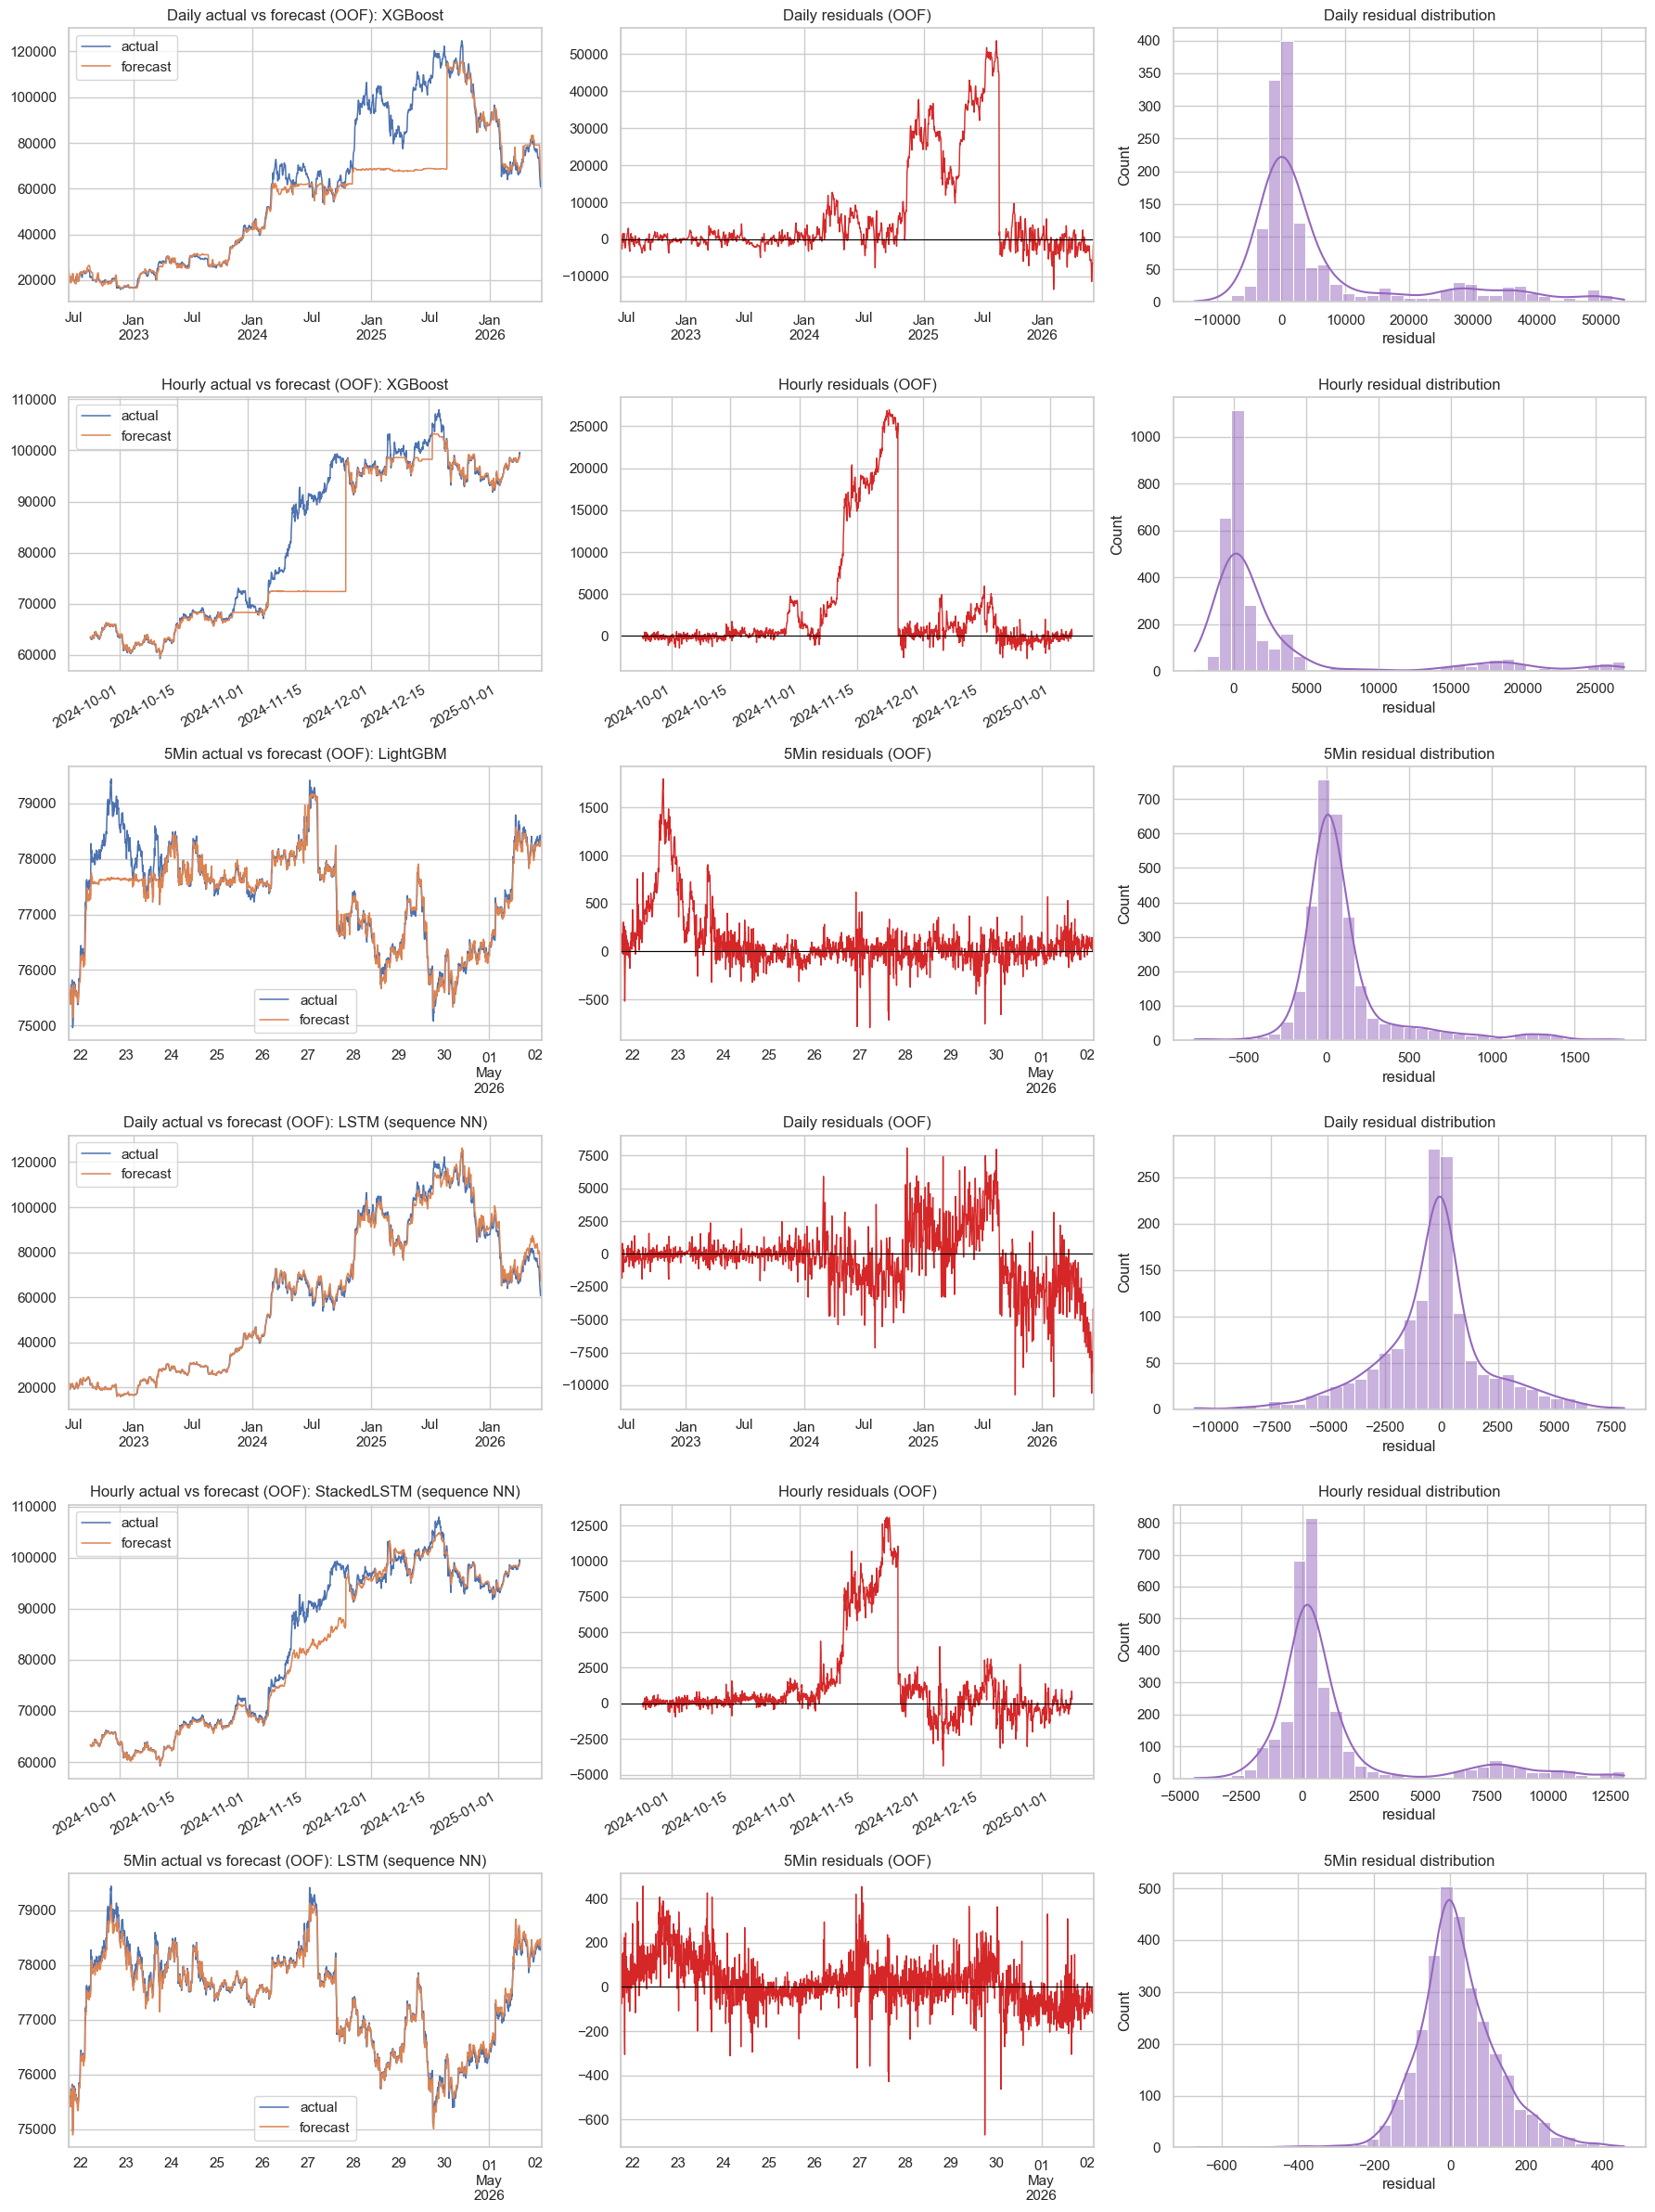

In [25]:
def residual_frame(frequency, model_name):
    """Residual frame from walk-forward OOF predictions."""
    oof_pred = prediction_store[frequency][model_name]['test_pred'].sort_index().dropna()
    actual = datasets[frequency]['BTC'].reindex(oof_pred.index)
    frame = pd.DataFrame({'actual': actual, 'forecast': oof_pred}).dropna()
    frame['residual'] = frame['actual'] - frame['forecast']
    frame['abs_error'] = frame['residual'].abs()
    frame['pct_return'] = frame['actual'].pct_change()
    return frame

error_analysis_rows = pd.concat([best_gb, best_nn]).reset_index(drop=True)

fig, axes = plt.subplots(len(error_analysis_rows), 3, figsize=(18, 4 * len(error_analysis_rows)))
if len(error_analysis_rows) == 1:
    axes = np.array([axes])

for row_idx, (_, row) in enumerate(error_analysis_rows.iterrows()):
    frequency = row['frequency']
    model_name = row['model']
    frame = residual_frame(frequency, model_name)

    frame[['actual', 'forecast']].plot(ax=axes[row_idx, 0], linewidth=1.1)
    axes[row_idx, 0].set_title(f'{frequency.title()} actual vs forecast (OOF): {model_name}')
    axes[row_idx, 0].set_xlabel('')

    frame['residual'].plot(ax=axes[row_idx, 1], color='tab:red', linewidth=1.0)
    axes[row_idx, 1].axhline(0, color='black', linewidth=0.8)
    axes[row_idx, 1].set_title(f'{frequency.title()} residuals (OOF)')
    axes[row_idx, 1].set_xlabel('')

    sns.histplot(frame['residual'], bins=35, kde=True, ax=axes[row_idx, 2], color='tab:purple')
    axes[row_idx, 2].set_title(f'{frequency.title()} residual distribution')

plt.tight_layout()
plt.show()


In [26]:
# Shock-period error analysis.
# Segments the OOF test window into "sharp growth" / "sharp drop" / "normal"
# using |return| > k * std(returns) with k=2 (primary) and k=3 (sensitivity check).
# Computes MAE and SMAPE per segment for the best GB, best NN, and both baselines.
SHOCK_K_VALUES = [2, 3]

baseline_wf = wf_agg[wf_agg['family'] == 'baseline']
shock_candidates = pd.concat([baseline_wf, best_gb, best_nn]).reset_index(drop=True)

shock_rows = []
shock_detail_rows = []

for k in SHOCK_K_VALUES:
    for _, row in shock_candidates.iterrows():
        frequency = row['frequency']
        model_name = row['model']
        frame = residual_frame(frequency, model_name).dropna(subset=['pct_return'])

        # Threshold = k standard deviations of the OOF return series
        ret_std = frame['pct_return'].std()
        threshold = k * ret_std

        frame = frame.copy()
        frame['shock_type'] = np.where(
            frame['pct_return'] >= threshold,
            'sharp growth',
            np.where(frame['pct_return'] <= -threshold, 'sharp drop', 'normal'),
        )

        oof_start_pos = datasets[frequency].index.get_loc(frame.index[0])
        y_train_proxy = datasets[frequency]['BTC'].iloc[:oof_start_pos].to_numpy(dtype=float)

        for shock_type, group in frame.groupby('shock_type'):
            metrics = regression_metrics(
                group['actual'], group['forecast'],
                y_train_proxy if len(y_train_proxy) > 1 else group['actual'].values,
            )
            shock_rows.append({
                'k': k,
                'frequency': frequency,
                'model': model_name,
                'period_type': shock_type,
                'threshold_pct': round(threshold * 100, 3),
                'n_observations': len(group),
                'MAE': metrics['MAE'],
                'SMAPE': metrics['SMAPE'],
                'MASE': metrics['MASE'],
            })

        # Collect top-10 individual shocks (k=2 only, to avoid duplication)
        if k == 2:
            shocks = frame[frame['shock_type'] != 'normal'].copy()
            shocks['abs_pct_return'] = shocks['pct_return'].abs()
            for time, values in shocks.sort_values('abs_pct_return', ascending=False).head(10).iterrows():
                shock_detail_rows.append({
                    'frequency': frequency,
                    'model': model_name,
                    'time': time,
                    'shock_type': values['shock_type'],
                    'pct_return': values['pct_return'],
                    'actual': values['actual'],
                    'forecast': values['forecast'],
                    'abs_error': values['abs_error'],
                })

shock_summary = pd.DataFrame(shock_rows)
shock_details = pd.DataFrame(shock_detail_rows)

# Primary table: k=2
print('Shock-period error analysis (|return| > 2 * std):')
display(
    shock_summary[shock_summary['k'] == 2]
    .drop(columns='k')
    .round({'MAE': 2, 'SMAPE': 3, 'MASE': 3, 'threshold_pct': 3})
)

# Sensitivity: k=3
print('\nSensitivity check (|return| > 3 * std):')
display(
    shock_summary[shock_summary['k'] == 3]
    .drop(columns='k')
    .round({'MAE': 2, 'SMAPE': 3, 'MASE': 3, 'threshold_pct': 3})
)

print('\nTop individual shocks per frequency/model (k=2 threshold):')
display(shock_details.round({'pct_return': 4, 'actual': 2, 'forecast': 2, 'abs_error': 2}))


Shock-period error analysis (|return| > 2 * std):


,frequency,model,period_type,threshold_pct,n_observations,MAE,SMAPE,MASE
0,daily,Moving average,normal,4.125,1368,1610.63,2.707,3.261
1,daily,Moving average,sharp drop,4.125,37,4335.74,8.021,8.779
2,daily,Moving average,sharp growth,4.125,49,3360.04,7.649,6.804
3,daily,Naive last value,normal,4.125,1368,724.13,1.174,1.466
4,daily,Naive last value,sharp drop,4.125,37,3269.90,5.893,6.621
5,daily,Naive last value,sharp growth,4.125,49,2617.13,5.536,5.299
6,hourly,Moving average,normal,0.764,2814,713.50,0.852,4.777
7,hourly,Moving average,sharp drop,0.764,90,1441.51,1.633,9.652
8,hourly,Moving average,sharp growth,0.764,95,1702.69,1.945,11.401
9,hourly,Naive last value,normal,0.764,2814,147.53,0.178,0.988



Sensitivity check (|return| > 3 * std):


,frequency,model,period_type,threshold_pct,n_observations,MAE,SMAPE,MASE
36,daily,Moving average,normal,6.188,1431,1689.42,2.883,3.421
37,daily,Moving average,sharp drop,6.188,10,5608.05,12.854,11.356
38,daily,Moving average,sharp growth,6.188,13,4213.02,9.188,8.531
39,daily,Naive last value,normal,6.188,1431,807.64,1.334,1.635
40,daily,Naive last value,sharp drop,6.188,10,3866.45,8.701,7.829
41,daily,Naive last value,sharp growth,6.188,13,3495.01,7.557,7.077
42,hourly,Moving average,normal,1.146,2938,744.47,0.885,4.985
43,hourly,Moving average,sharp drop,1.146,30,1497.37,1.669,10.026
44,hourly,Moving average,sharp growth,1.146,31,2164.20,2.566,14.491
45,hourly,Naive last value,normal,1.146,2938,175.26,0.209,1.174



Top individual shocks per frequency/model (k=2 threshold):


,frequency,model,time,shock_type,pct_return,actual,forecast,abs_error
0,daily,Moving average,2022-11-09 00:00:00,sharp drop,-0.1236,16508.68,20466.33,3957.65
1,daily,Moving average,2026-02-05 00:00:00,sharp drop,-0.1146,65229.82,78958.05,13728.23
2,daily,Moving average,2023-03-13 00:00:00,sharp growth,0.0909,23716.03,21370.24,2345.79
3,daily,Moving average,2023-10-23 00:00:00,sharp growth,0.0895,32660.18,29035.47,3624.71
4,daily,Moving average,2022-11-08 00:00:00,sharp drop,-0.0894,18837.67,20703.01,1865.34
...,...,...,...,...,...,...,...,...
115,5min,LSTM (sequence NN),2026-05-01 13:50:00,sharp growth,0.0047,78699.09,78390.62,308.47
116,5min,LSTM (sequence NN),2026-04-22 02:10:00,sharp growth,0.0046,76687.41,76303.94,383.47
117,5min,LSTM (sequence NN),2026-04-27 15:00:00,sharp drop,-0.0046,77477.73,77862.94,385.21
118,5min,LSTM (sequence NN),2026-04-23 17:50:00,sharp growth,0.0045,77611.87,77205.50,406.37


## Discussion

This experiment is structured around the four research questions of the thesis ("Bitcoin Price Forecasting: Boosting Ensembles vs. Neural Networks").

**Q1: Which family has lower error — Gradient Boosting or the Neural Networks?**
The walk-forward aggregate table (`wf_agg`) reports mean OOF SMAPE/MAE/RMSE/MASE across all five folds for every model and frequency. `Naive last value` is the reference: any model that does not approach persistence-level error at a short horizon adds no practical forecasting value. The `headline` bar chart shows the best GB model (`best_gb`) and the best NN architecture (`best_nn`) alongside the two baselines per frequency. Whichever family achieves the lower mean OOF SMAPE is read as the stronger family for that granularity.

**Q2: How does the GB-vs-NN gap change across granularities (Daily → Hourly → 5-minute)?**
Define the gap as `SMAPE(best_gb) − SMAPE(best_nn)` per frequency from `wf_agg`. A positive gap favors the NN; negative favors GB. Tracking this across frequencies reveals whether the NN's sequence modeling becomes more (or less) valuable as the sampling interval shrinks: at 5-minute granularity the fixed `window_size` in `NN_CONFIG` covers only a few hours of real-time history, whereas at daily granularity it spans ten calendar days. This asymmetry is a deliberate part of the comparison design.

**Q3: Which features matter most for each family's best model?**
Permutation importance and SHAP `TreeExplainer` summary plots answer Q3 for `best_gb`; Captum Integrated Gradients (exogenous branch, zero baseline) answers it for `best_nn`. The IG attribution isolates each feature's marginal contribution relative to "no exogenous signal", holding the BTC sequence context fixed — a cleaner attribution than the raw backward gradient used in earlier work. Overlap between the two rankings suggests the predictive signal is robust to model choice; divergence identifies family-specific sources of advantage.

**Q4: How do error patterns differ during sharp BTC growth vs. decline?**
The shock analysis segments the OOF test set using `|return| > k × std(returns)` with k = 2 (primary) and k = 3 (sensitivity), which adapts the threshold to the volatility of each frequency rather than fixing it at the 90th percentile. MAE/SMAPE/MASE are reported for `Naive last value`, `best_gb`, and `best_nn` within each segment. A model that degrades less than `Naive last value` during shocks has genuine predictive value in the periods most relevant for risk management; a model that degrades more is effectively lagging the shock, similar to persistence but with extra modeling cost.


## Conclusion

This notebook is an executable walk-forward comparison of Gradient Boosting ensembles (HistGradientBoosting, LightGBM, XGBoost, CatBoost) against four Neural Network sequence architectures (LSTM, GRU, Stacked LSTM, CNN-LSTM, all built with `CryptoNet`) for one-step-ahead BTC forecasting at Daily, Hourly, and 5-minute granularities.

The walk-forward protocol (5 folds per frequency, expanding window for Daily and rolling window for Hourly/5-min) avoids look-ahead bias: feature selection (top-k by |Pearson| on train fold only), preprocessing (impute/clip/scale), and hyperparameter tuning (Optuna, TimeSeriesSplit CV inside train fold) are all scoped to each fold's training data before any test observation is touched.

The `wf_agg` table and `headline` bar chart answer research question 1 (which family achieves lower OOF SMAPE) and, read across frequencies, research question 2 (how the GB-vs-NN gap evolves from Daily to 5-minute). Permutation importance / SHAP `TreeExplainer` for `best_gb` and Captum Integrated Gradients for `best_nn` answer research question 3 (which features each family relies on). The shock analysis (|return| > k × std, k = 2/3) answers research question 4 (how errors change during sharp BTC growth and decline events).

`Naive last value` remains a strong benchmark at every frequency, consistent with BTC's near-random-walk behavior at short horizons. Both GB and the NNs should be assessed relative to this persistence baseline rather than in absolute terms.

Main limitations: BTC non-stationarity and regime shifts across the OOF period; weak extrapolation outside the training price range; a fixed `window_size` in `NN_CONFIG` that covers different real-time horizons at different frequencies; and the difficulty of anticipating crypto shocks from tabular/sequence indicators alone.

Further work: online/adaptive retraining to track regime changes; probabilistic/quantile forecasts; richer on-chain and order-book features targeting the shock segments identified in Q4; and an ablation comparing fixed vs. per-fold hyperparameters to quantify the Optuna retuning cost against its OOF error reduction.
